In [22]:
import numpy as np
import matplotlib.pyplot as plt

class svm_rattrapage:
    def __init__(self, learning_rate=0.001, lambda_param=0.01, n_iters=15000):
        # initialisation des paramètres : taux d'apprentissage, régularisation et itérations
        self.lr = learning_rate
        self.lambda_param = lambda_param
        self.n_iters = n_iters
        self.w = None
        self.b = None

    def fit(self, x, y):
        # initialisation des poids w et du biais b à zéro
        n_samples, n_features = x.shape
        self.w = np.zeros(n_features)
        self.b = 0

        # boucle d'optimisation (descente de gradient)
        for _ in range(self.n_iters):
            for idx, x_i in enumerate(x):
                # calcul de la condition de marge : y_i * (w.x - b) >= 1
                condition = y[idx] * (np.dot(x_i, self.w) - self.b) >= 1

                if condition:
                    # si le point est bien classé : on réduit seulement les poids (régularisation)
                    self.w -= self.lr * (2 * self.lambda_param * self.w)
                else:
                    # si le point est mal classé : on ajuste w et b pour réduire l'erreur
                    self.w -= self.lr * (2 * self.lambda_param * self.w - np.dot(x_i, y[idx]))
                    self.b -= self.lr * y[idx]

    def predict(self, x):
        # calcule la sortie linéaire et retourne le signe (-1 ou 1)
        linear_output = np.dot(x, self.w) - self.b
        return np.sign(linear_output)

In [23]:
# données initiales (ceux qui ont échoué en session normale)
x_init = np.array([[1.5, 3], [1, 1], [2, 1], [3, 2], [4, 4], [2, 5]])

# données des étudiants ayant déjà réussi
x_success = np.array([[6, 7], [8, 9], [7, 8], [9, 7], [7, 9], [8, 6]])

# fusion des deux groupes pour l'entraînement du modèle
x_total = np.vstack((x_init, x_success))
y_total = np.array([-1, -1, -1, -1, -1, -1, 1, 1, 1, 1, 1, 1])

# entraînement du modèle sur les résultats de la session normale
model = svm_rattrapage()
model.fit(x_total, y_total)

# simulation du rattrapage : on augmente les heures d'étude et la participation
x_rattrapage = x_init.copy()
x_rattrapage[:, 0] += 3.5  # augmentation de l'effort (x1)
x_rattrapage[:, 1] += 2.0  # augmentation de la participation (x2)

# prédiction pour voir qui a réussi grâce à cet effort supplémentaire
y_final_pred = model.predict(x_rattrapage)

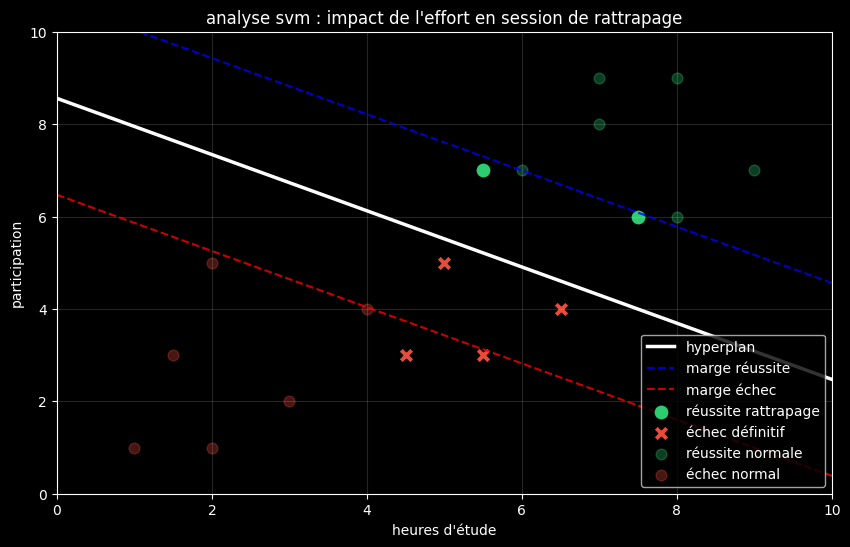

In [24]:
def visualize_rattrapage():
    # fonction pour définir la droite y = ax + b à partir de l'hyperplan
    def get_hyperplane_value(x, v):
        return (-model.w[0] * x + model.b + v) / model.w[1]

    plt.figure(figsize=(10, 6))
    plt.style.use('dark_background') # utilisation du style sombre

    x_range = np.array([0, 10])

    # tracé de la frontière de décision (en blanc)
    plt.plot(x_range, get_hyperplane_value(x_range, 0), 'w-', linewidth=2.5, label='hyperplan')

    # tracé des marges de sécurité (vecteurs supports)
    plt.plot(x_range, get_hyperplane_value(x_range, 1), 'b--', alpha=0.8, label='marge réussite')
    plt.plot(x_range, get_hyperplane_value(x_range, -1), 'r--', alpha=0.8, label='marge échec')

    # affichage des étudiants après rattrapage (réussite en vert, échec en rouge)
    reussite = x_rattrapage[y_final_pred == 1]
    plt.scatter(reussite[:,0], reussite[:,1], color='#2ecc71', s=120, edgecolors='k', label='réussite rattrapage')

    echec = x_rattrapage[y_final_pred == -1]
    plt.scatter(echec[:,0], echec[:,1], color='#e74c3c', marker='X', s=120, edgecolors='k', label='échec définitif')

    # rappel des positions initiales en semi-transparent pour comparaison
    plt.scatter(x_success[:,0], x_success[:,1], color='#2ecc71', s=60, alpha=0.3, label='réussite normale')
    plt.scatter(x_init[:,0], x_init[:,1], color='#e74c3c', s=60, alpha=0.3, label='échec normal')

    plt.title("analyse svm : impact de l'effort en session de rattrapage")
    plt.xlabel('heures d\'étude')
    plt.ylabel('participation')
    plt.xlim(0, 10)
    plt.ylim(0, 10)
    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.15) # True avec majuscule obligatoire
    plt.show()

# exécution de la visualisation
visualize_rattrapage()